# Baseline Model Training
Train logistic regression models on both feature sets and compare performance.

**Models:**
- Model A: 20 features (broader set)
- Model B: 7 features (trimmed, low redundancy)

**Evaluation:**
- Accuracy, Precision, Recall, F1
- ROC-AUC
- Cross-validation to avoid overfitting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

sns.set_theme(style='whitegrid')
np.random.seed(42)

## 1. Load Data

In [2]:
# Load both datasets
df_a = pd.read_csv('../data/processed/matchups_model_a.csv')
df_b = pd.read_csv('../data/processed/matchups_model_b.csv')

print(f'Model A: {df_a.shape}')
print(f'Model B: {df_b.shape}')

# Feature columns (everything except metadata)
meta_cols = ['season', 'round', 'home_team', 'away_team', 'home_seed', 'away_seed', 
             'home_score', 'away_score', 'home_win']

features_a = [c for c in df_a.columns if c not in meta_cols]
features_b = [c for c in df_b.columns if c not in meta_cols]

print(f'\nModel A features ({len(features_a)}): {features_a}')
print(f'\nModel B features ({len(features_b)}): {features_b}')

Model A: (477, 29)
Model B: (477, 16)

Model A features (20): ['diff_srs', 'diff_win_pct', 'diff_sos', 'diff_ortg', 'diff_efg_pct', 'diff_tov_pct', 'diff_orb_pct', 'seed_diff', 'diff_ftr', 'diff_ts_pct', 'diff_ft_pct', 'diff_pace', 'diff_pts_for', 'diff_pts_against', 'diff_ast_pct', 'diff_stl_pct', 'diff_blk_pct', 'diff_trb_pct', 'diff_three_par', 'diff_three_pct']

Model B features (7): ['diff_srs', 'diff_win_pct', 'diff_efg_pct', 'diff_tov_pct', 'diff_orb_pct', 'diff_ftr', 'seed_diff']


In [3]:
# Prepare X and y
X_a = df_a[features_a].values
X_b = df_b[features_b].values
y = df_a['home_win'].values

print(f'X_a shape: {X_a.shape}')
print(f'X_b shape: {X_b.shape}')
print(f'y shape: {y.shape}')
print(f'Class balance: {y.mean():.1%} home wins')

X_a shape: (477, 20)
X_b shape: (477, 7)
y shape: (477,)
Class balance: 67.1% home wins


## 2. Train/Test Split
Use seasons 2014-2022 for training, 2023-2024 for testing (temporal split).

In [4]:
# Temporal split: train on older seasons, test on recent
train_mask = df_a['season'] <= 2022
test_mask = df_a['season'] >= 2023

X_train_a, X_test_a = X_a[train_mask], X_a[test_mask]
X_train_b, X_test_b = X_b[train_mask], X_b[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f'Training set: {len(y_train)} games (2014-2022)')
print(f'Test set: {len(y_test)} games (2023-2024)')
print(f'Train class balance: {y_train.mean():.1%}')
print(f'Test class balance: {y_test.mean():.1%}')

Training set: 388 games (2014-2022)
Test set: 89 games (2023-2024)
Train class balance: 67.8%
Test class balance: 64.0%


In [5]:
# Scale features (important for logistic regression)
scaler_a = StandardScaler()
scaler_b = StandardScaler()

X_train_a_scaled = scaler_a.fit_transform(X_train_a)
X_test_a_scaled = scaler_a.transform(X_test_a)

X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

print('Features scaled using StandardScaler')

Features scaled using StandardScaler


## 3. Train Logistic Regression Models

In [6]:
# Model A: 20 features
model_a = LogisticRegression(max_iter=1000, random_state=42)
model_a.fit(X_train_a_scaled, y_train)

# Model B: 7 features
model_b = LogisticRegression(max_iter=1000, random_state=42)
model_b.fit(X_train_b_scaled, y_train)

print('Models trained!')

Models trained!


## 4. Cross-Validation (on training data)

In [7]:
# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_a = cross_val_score(model_a, X_train_a_scaled, y_train, cv=cv, scoring='accuracy')
cv_scores_b = cross_val_score(model_b, X_train_b_scaled, y_train, cv=cv, scoring='accuracy')

print('Cross-Validation Accuracy (5-fold):')
print(f'  Model A (20 features): {cv_scores_a.mean():.3f} ± {cv_scores_a.std():.3f}')
print(f'  Model B (7 features):  {cv_scores_b.mean():.3f} ± {cv_scores_b.std():.3f}')

Cross-Validation Accuracy (5-fold):
  Model A (20 features): 0.838 ± 0.030
  Model B (7 features):  0.745 ± 0.034


## 5. Test Set Evaluation

In [8]:
# Predictions
y_pred_a = model_a.predict(X_test_a_scaled)
y_pred_b = model_b.predict(X_test_b_scaled)
y_prob_a = model_a.predict_proba(X_test_a_scaled)[:, 1]
y_prob_b = model_b.predict_proba(X_test_b_scaled)[:, 1]

# Metrics
def evaluate_model(y_true, y_pred, y_prob, name):
    print(f'\n{name}')
    print('='*40)
    print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.3f}')
    print(f'  Precision: {precision_score(y_true, y_pred):.3f}')
    print(f'  Recall:    {recall_score(y_true, y_pred):.3f}')
    print(f'  F1 Score:  {f1_score(y_true, y_pred):.3f}')
    print(f'  ROC-AUC:   {roc_auc_score(y_true, y_prob):.3f}')
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_prob)
    }

metrics_a = evaluate_model(y_test, y_pred_a, y_prob_a, 'Model A (20 features)')
metrics_b = evaluate_model(y_test, y_pred_b, y_prob_b, 'Model B (7 features)')


Model A (20 features)
  Accuracy:  0.775
  Precision: 0.814
  Recall:    0.842
  F1 Score:  0.828
  ROC-AUC:   0.861

Model B (7 features)
  Accuracy:  0.719
  Precision: 0.750
  Recall:    0.842
  F1 Score:  0.793
  ROC-AUC:   0.769


In [9]:
# Comparison table
comparison = pd.DataFrame({
    'Model A (20 features)': metrics_a,
    'Model B (7 features)': metrics_b
}).T

comparison['features'] = [20, 7]
comparison = comparison[['features', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
print('\nModel Comparison:')
comparison


Model Comparison:


,features,accuracy,precision,recall,f1,roc_auc
Model A (20 features),20,0.775281,0.813559,0.842105,0.827586,0.861294
Model B (7 features),7,0.719101,0.750000,0.842105,0.793388,0.769189


## 6. Visualizations

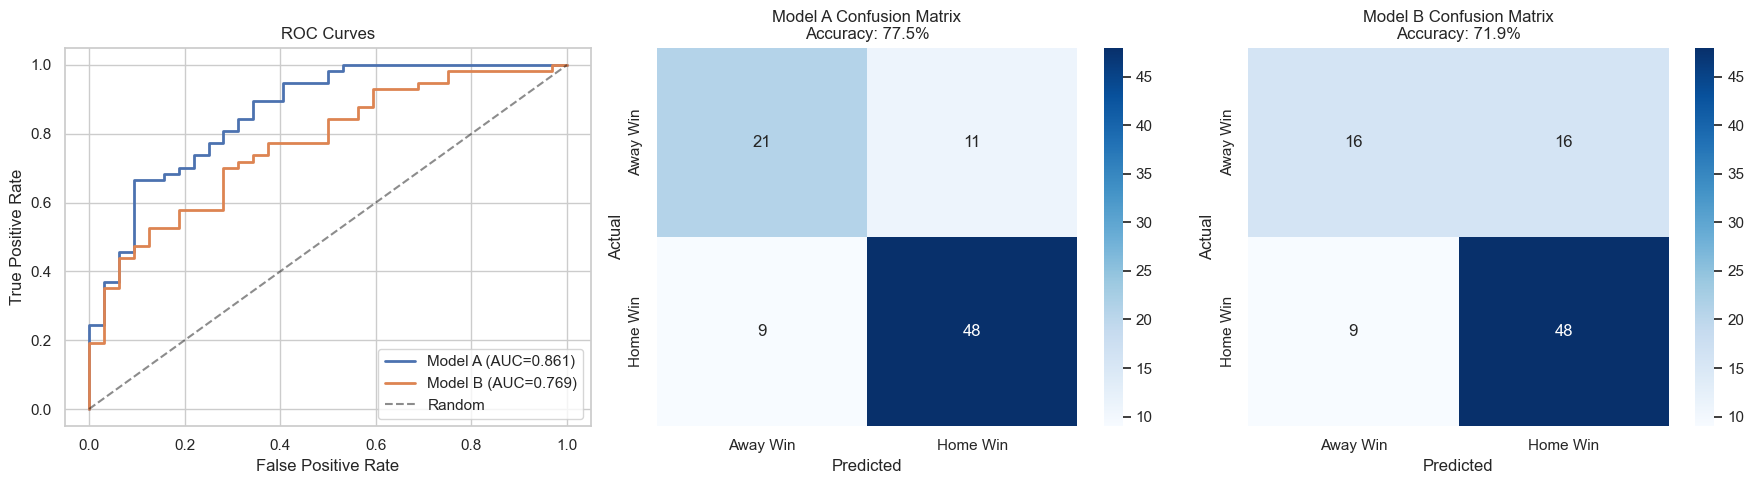

In [10]:
# ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
ax = axes[0]
fpr_a, tpr_a, _ = roc_curve(y_test, y_prob_a)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_b)

ax.plot(fpr_a, tpr_a, label=f'Model A (AUC={metrics_a["roc_auc"]:.3f})', linewidth=2)
ax.plot(fpr_b, tpr_b, label=f'Model B (AUC={metrics_b["roc_auc"]:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

# Confusion Matrix - Model A
ax = axes[1]
cm_a = confusion_matrix(y_test, y_pred_a)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Model A Confusion Matrix\nAccuracy: {metrics_a["accuracy"]:.1%}')

# Confusion Matrix - Model B
ax = axes[2]
cm_b = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Model B Confusion Matrix\nAccuracy: {metrics_b["accuracy"]:.1%}')

plt.tight_layout()
plt.savefig('../results/visualizations/baseline_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

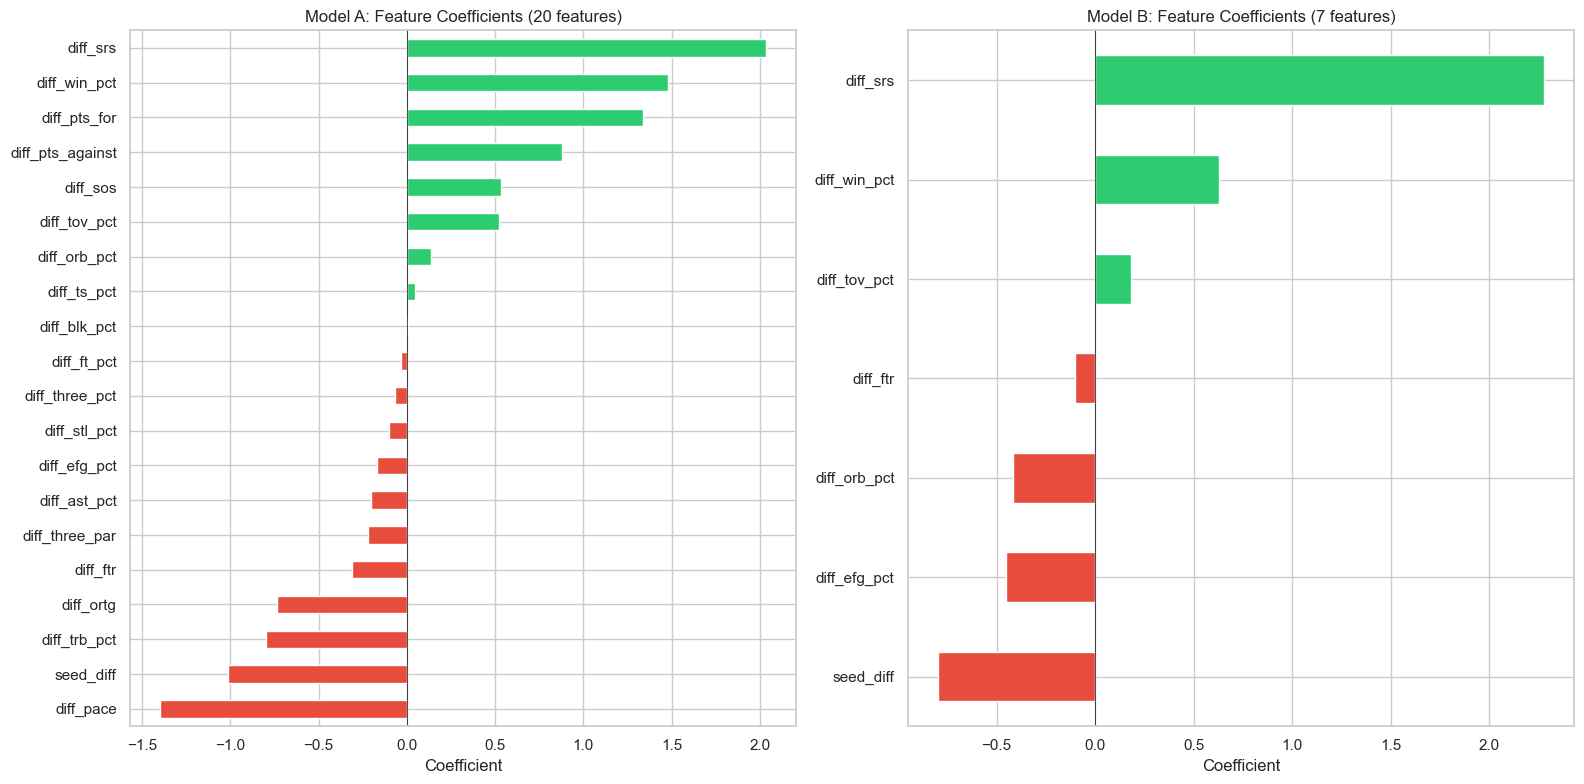

In [11]:
# Feature importance (coefficients)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Model A coefficients
coef_a = pd.Series(model_a.coef_[0], index=features_a).sort_values()
ax = axes[0]
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_a.values]
coef_a.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Coefficient')
ax.set_title('Model A: Feature Coefficients (20 features)')
ax.axvline(x=0, color='black', linewidth=0.5)

# Model B coefficients
coef_b = pd.Series(model_b.coef_[0], index=features_b).sort_values()
ax = axes[1]
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_b.values]
coef_b.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Coefficient')
ax.set_title('Model B: Feature Coefficients (7 features)')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../results/visualizations/baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Analyze Predictions by Seed Matchup

In [12]:
# Add predictions to test dataframe
test_df = df_a[test_mask].copy()
test_df['pred_a'] = y_pred_a
test_df['pred_b'] = y_pred_b
test_df['prob_a'] = y_prob_a
test_df['prob_b'] = y_prob_b
test_df['correct_a'] = (test_df['pred_a'] == test_df['home_win']).astype(int)
test_df['correct_b'] = (test_df['pred_b'] == test_df['home_win']).astype(int)

# Accuracy by seed differential
test_df['seed_matchup'] = test_df.apply(
    lambda r: f"{int(min(r['home_seed'], r['away_seed']))} vs {int(max(r['home_seed'], r['away_seed']))}", 
    axis=1
)

print('Accuracy by seed matchup type:')
seed_accuracy = test_df.groupby('seed_matchup').agg({
    'correct_a': 'mean',
    'correct_b': 'mean',
    'home_win': 'count'
}).rename(columns={'correct_a': 'Model A', 'correct_b': 'Model B', 'home_win': 'Games'})
seed_accuracy = seed_accuracy.sort_values('Games', ascending=False)
seed_accuracy

Accuracy by seed matchup type:


,Model A,Model B,Games
seed_matchup,,,
3 vs 14,0.833333,1.000000,6
8 vs 9,0.833333,0.833333,6
2 vs 15,0.833333,0.833333,6
7 vs 10,0.500000,0.166667,6
4 vs 5,0.800000,0.800000,5
1 vs 16,1.000000,1.000000,5
5 vs 12,0.600000,0.800000,5
6 vs 11,0.800000,0.200000,5
4 vs 13,0.500000,0.500000,4


In [13]:
# Upset detection: Did the model correctly predict when the lower-seeded team won?
test_df['favorite_seed'] = test_df[['home_seed', 'away_seed']].min(axis=1)
test_df['underdog_seed'] = test_df[['home_seed', 'away_seed']].max(axis=1)
test_df['upset'] = ((test_df['home_seed'] > test_df['away_seed']) & (test_df['home_win'] == 1)) | \
                   ((test_df['away_seed'] > test_df['home_seed']) & (test_df['home_win'] == 0))

upsets = test_df[test_df['upset'] == True]
non_upsets = test_df[test_df['upset'] == False]

print(f'\nUpset Analysis (2023-2024 tournaments):')
print(f'  Total games: {len(test_df)}')
print(f'  Upsets: {len(upsets)} ({len(upsets)/len(test_df):.1%})')
print(f'  Chalk (favorite wins): {len(non_upsets)} ({len(non_upsets)/len(test_df):.1%})')
print(f'\n  Model A accuracy on upsets: {upsets["correct_a"].mean():.1%}')
print(f'  Model B accuracy on upsets: {upsets["correct_b"].mean():.1%}')
print(f'  Model A accuracy on chalk: {non_upsets["correct_a"].mean():.1%}')
print(f'  Model B accuracy on chalk: {non_upsets["correct_b"].mean():.1%}')


Upset Analysis (2023-2024 tournaments):
  Total games: 89
  Upsets: 27 (30.3%)
  Chalk (favorite wins): 62 (69.7%)

  Model A accuracy on upsets: 63.0%
  Model B accuracy on upsets: 48.1%
  Model A accuracy on chalk: 83.9%
  Model B accuracy on chalk: 82.3%


## 8. Save Models

In [14]:
# Create models directory
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# Save models and scalers
joblib.dump(model_a, models_dir / 'logistic_model_a.pkl')
joblib.dump(model_b, models_dir / 'logistic_model_b.pkl')
joblib.dump(scaler_a, models_dir / 'scaler_a.pkl')
joblib.dump(scaler_b, models_dir / 'scaler_b.pkl')

# Save feature lists
joblib.dump(features_a, models_dir / 'features_a.pkl')
joblib.dump(features_b, models_dir / 'features_b.pkl')

print('Saved:')
print('  - logistic_model_a.pkl (20 features)')
print('  - logistic_model_b.pkl (7 features)')
print('  - scaler_a.pkl, scaler_b.pkl')
print('  - features_a.pkl, features_b.pkl')

Saved:
  - logistic_model_a.pkl (20 features)
  - logistic_model_b.pkl (7 features)
  - scaler_a.pkl, scaler_b.pkl
  - features_a.pkl, features_b.pkl


## 9. Summary

In [15]:
print('='*60)
print('BASELINE MODEL SUMMARY')
print('='*60)
print(f'\nTraining data: {len(y_train)} games (2014-2022)')
print(f'Test data: {len(y_test)} games (2023-2024)')
print(f'\nModel A (20 features):')
print(f'  - CV Accuracy: {cv_scores_a.mean():.1%} ± {cv_scores_a.std():.1%}')
print(f'  - Test Accuracy: {metrics_a["accuracy"]:.1%}')
print(f'  - Test ROC-AUC: {metrics_a["roc_auc"]:.3f}')
print(f'\nModel B (7 features):')
print(f'  - CV Accuracy: {cv_scores_b.mean():.1%} ± {cv_scores_b.std():.1%}')
print(f'  - Test Accuracy: {metrics_b["accuracy"]:.1%}')
print(f'  - Test ROC-AUC: {metrics_b["roc_auc"]:.3f}')
print(f'\nGoal: >73% accuracy')
print('='*60)

BASELINE MODEL SUMMARY

Training data: 388 games (2014-2022)
Test data: 89 games (2023-2024)

Model A (20 features):
  - CV Accuracy: 83.8% ± 3.0%
  - Test Accuracy: 77.5%
  - Test ROC-AUC: 0.861

Model B (7 features):
  - CV Accuracy: 74.5% ± 3.4%
  - Test Accuracy: 71.9%
  - Test ROC-AUC: 0.769

Goal: >73% accuracy
